# NLP Feature Engineering -- FinBERT Sentiment & Sentence Embeddings

This notebook processes the news dataset through two NLP pipelines:

1. **FinBERT** (`ProsusAI/finbert`) -- financial sentiment scoring (positive / negative / neutral)
2. **Sentence-Transformers** (`all-MiniLM-L6-v2`) -- dense semantic embeddings, reduced via PCA

Results are aggregated to daily per-ticker features aligned with trading days, then saved for merging with price features.

**Input:** `news.csv`, `price.csv` (for trading day calendar)

**Output:** `features_nlp.csv` -- daily NLP features per ticker

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '.'
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

/Users/nikorose87/.conda/envs/stock-pred/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


## 1. Load Data

In [2]:
news_df = pd.read_csv(f'{DATA_DIR}/news.csv', parse_dates=['datetime'])
price_df = pd.read_csv(f'{DATA_DIR}/price.csv', parse_dates=['date'])

tickers = sorted(price_df['ticker'].unique())
trading_dates = sorted(price_df['date'].dt.date.unique())

print(f'News articles: {len(news_df)}')
print(f'Tickers: {tickers}')
print(f'Trading days: {len(trading_dates)}')
print(f'\nSample articles:')
display(news_df.head(3))

News articles: 4440
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Trading days: 241

Sample articles:


,datetime,ticker,headline,summary
0,2024-10-29 18:07:48,AAPL,Apple Unveils the Redesigned Mac Mini,-- Apple overhauled the design of its Mac mini...
1,2024-10-29 02:21:10,AAPL,Apple blocked from selling iPhone 16 in Indone...,TECH giant Apple will not be allowed to sell i...
2,2024-10-28 14:05:22,AAPL,"Apple Rises on Apple Intelligence Rollout, New...",-- Apple unveiled its new iMac and said Apple ...


## 2. Prepare Text for NLP

Combine headline + summary into a single text field. Fill missing summaries.

In [3]:
news_df['summary'] = news_df['summary'].fillna('')
news_df['text'] = news_df['headline'] + '. ' + news_df['summary']
news_df['text'] = news_df['text'].str.strip()

# Truncate very long texts (FinBERT max is 512 tokens)
news_df['text_truncated'] = news_df['text'].str[:512]

print(f'Text length stats:')
print(f'  Mean: {news_df["text"].str.len().mean():.0f} chars')
print(f'  Median: {news_df["text"].str.len().median():.0f} chars')
print(f'  Max: {news_df["text"].str.len().max()} chars')
print(f'  Truncated (>512): {(news_df["text"].str.len() > 512).sum()} articles')

Text length stats:
  Mean: 259 chars
  Median: 261 chars
  Max: 551 chars
  Truncated (>512): 1 articles


## 3. FinBERT Sentiment Scoring

Score each article with `ProsusAI/finbert`. Output: positive, negative, neutral probabilities + compound score.

In [4]:
finbert_tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
finbert_model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')
finbert_model = finbert_model.to(DEVICE)
finbert_model.eval()

print('FinBERT loaded successfully')
print(f'Labels: {finbert_model.config.id2label}')

Loading weights: 100%|███████████████████████████████████████| 201/201 [00:00<00:00, 2284.82it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded successfully
Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


In [5]:
def finbert_batch_predict(texts, tokenizer, model, device, batch_size=32):
    """Run FinBERT inference in batches. Returns arrays of (positive, negative, neutral) probabilities."""
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=512, return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            all_probs.append(probs.cpu().numpy())

        if (i // batch_size) % 20 == 0:
            print(f'  Processed {min(i + batch_size, len(texts))}/{len(texts)} articles...')

    return np.vstack(all_probs)


print(f'Running FinBERT on {len(news_df)} articles...')
texts_list = news_df['text_truncated'].tolist()
sentiment_probs = finbert_batch_predict(texts_list, finbert_tokenizer, finbert_model, DEVICE)

# FinBERT label order: positive=0, negative=1, neutral=2
label_map = finbert_model.config.id2label
label_order = [label_map[i] for i in range(3)]
print(f'Label order: {label_order}')

for idx, label in enumerate(label_order):
    news_df[f'sent_{label}'] = sentiment_probs[:, idx]

# Compound score: positive - negative (range -1 to +1)
pos_col = f'sent_{label_order[label_order.index("positive")]}'
neg_col = f'sent_{label_order[label_order.index("negative")]}'
news_df['sent_compound'] = news_df[pos_col] - news_df[neg_col]

# Dominant sentiment label
sent_cols = [f'sent_{l}' for l in label_order]
news_df['sent_label'] = news_df[sent_cols].idxmax(axis=1).str.replace('sent_', '')

print(f'\nDone. Sentiment distribution:')
display(news_df['sent_label'].value_counts(normalize=True))

print(f'\nCompound score stats:')
display(news_df['sent_compound'].describe())

Running FinBERT on 4440 articles...
  Processed 32/4440 articles...
  Processed 672/4440 articles...
  Processed 1312/4440 articles...
  Processed 1952/4440 articles...
  Processed 2592/4440 articles...
  Processed 3232/4440 articles...
  Processed 3872/4440 articles...
Label order: ['positive', 'negative', 'neutral']

Done. Sentiment distribution:


sent_label
neutral     0.412387
positive    0.314414
negative    0.273198
Name: proportion, dtype: float64


Compound score stats:


count    4440.000000
mean        0.054753
std         0.629695
min        -0.969243
25%        -0.499005
50%         0.092602
75%         0.628392
max         0.942939
Name: sent_compound, dtype: float64

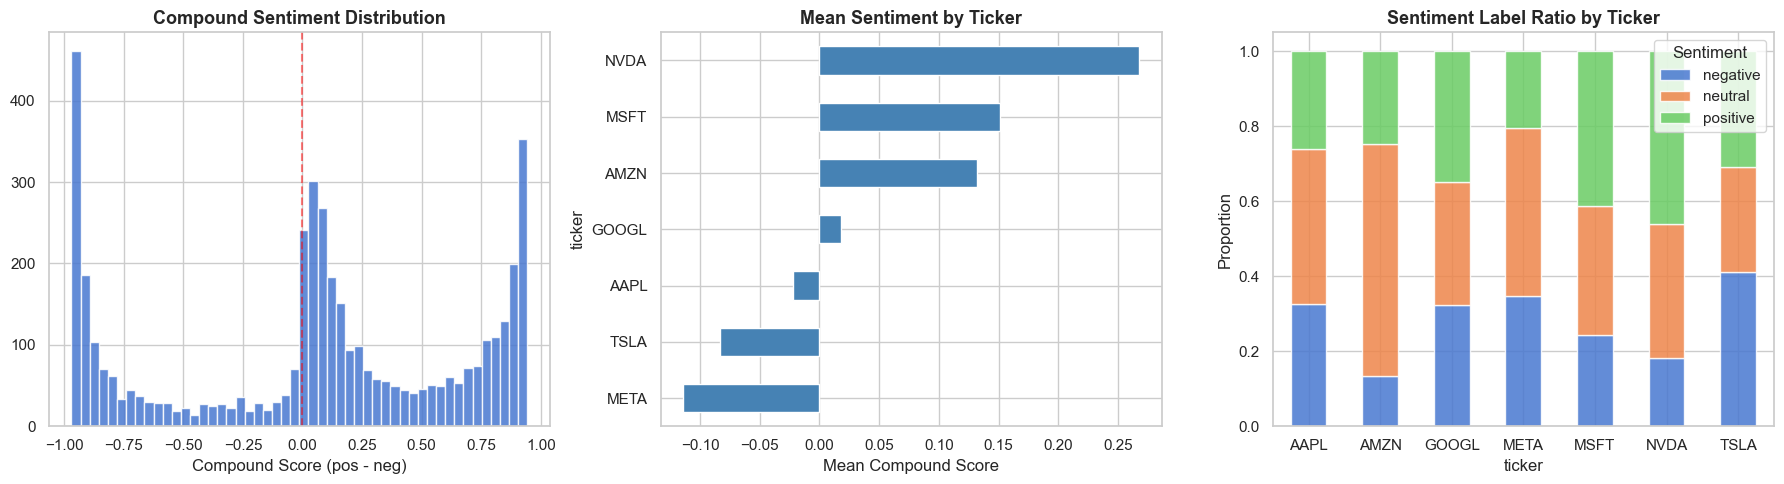

In [6]:
# Sentiment distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

news_df['sent_compound'].hist(bins=50, ax=axes[0], edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Compound Sentiment Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Compound Score (pos - neg)')

news_df.groupby('ticker')['sent_compound'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Mean Sentiment by Ticker', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Compound Score')

sent_counts = news_df.groupby(['ticker', 'sent_label']).size().unstack(fill_value=0)
sent_counts_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0)
sent_counts_pct.plot(kind='bar', stacked=True, ax=axes[2], alpha=0.85)
axes[2].set_title('Sentiment Label Ratio by Ticker', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Proportion')
axes[2].legend(title='Sentiment')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Sentence Embeddings

Encode headlines using `all-MiniLM-L6-v2` (384 dimensions), then reduce with PCA.

In [7]:
embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)

print(f'Encoding {len(news_df)} headlines...')
headline_embeddings = embed_model.encode(
    news_df['headline'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(f'Embedding shape: {headline_embeddings.shape}')

Loading weights: 100%|█████████████████████████████████| 103/103 [00:00<00:00, 13771.54it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 4440 headlines...


Batches: 100%|██████████████████████████████████████████████| 70/70 [00:04<00:00, 16.41it/s]

Embedding shape: (4440, 384)


PCA: 15 components explain 37.8% of variance


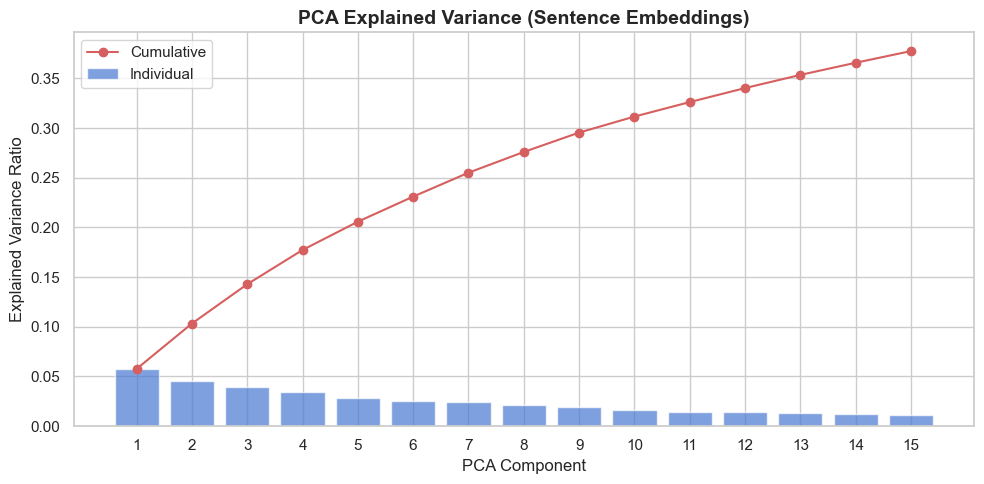

In [8]:
N_COMPONENTS = 15
pca = PCA(n_components=N_COMPONENTS, random_state=42)
embeddings_pca = pca.fit_transform(headline_embeddings)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f'PCA: {N_COMPONENTS} components explain {cumulative_var[-1]:.1%} of variance')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, N_COMPONENTS + 1), explained_var, alpha=0.7, label='Individual')
ax.plot(range(1, N_COMPONENTS + 1), cumulative_var, 'ro-', label='Cumulative')
ax.set_xlabel('PCA Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Explained Variance (Sentence Embeddings)', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(range(1, N_COMPONENTS + 1))
plt.tight_layout()
plt.show()

for i in range(N_COMPONENTS):
    news_df[f'emb_pca_{i}'] = embeddings_pca[:, i]

## 5. Temporal Alignment

Map each article to the correct trading day:
- Pre-market / during market hours -> same trading day
- After 16:00 ET -> next trading day
- Weekends / holidays -> next trading day

In [9]:
import bisect

trading_dates_sorted = sorted(trading_dates)


def assign_trading_day(dt):
    """Assign a news datetime to the appropriate trading day."""
    news_date = dt.date()
    news_hour = dt.hour

    if news_hour >= 16:
        target_date = news_date + pd.Timedelta(days=1)
    else:
        target_date = news_date

    idx = bisect.bisect_left(trading_dates_sorted, target_date)
    if idx >= len(trading_dates_sorted):
        return trading_dates_sorted[-1]
    return trading_dates_sorted[idx]


news_df['trading_day'] = news_df['datetime'].apply(assign_trading_day)
news_df['trading_day'] = pd.to_datetime(news_df['trading_day'])

shifted = (news_df['datetime'].dt.date != news_df['trading_day'].dt.date).sum()
print(f'Articles shifted to a different trading day: {shifted} / {len(news_df)} ({100*shifted/len(news_df):.1f}%)')

Articles shifted to a different trading day: 1082 / 4440 (24.4%)


## 6. Daily Aggregation Per Ticker

Aggregate all article-level features to daily per-ticker summaries.

In [10]:
emb_pca_cols = [f'emb_pca_{i}' for i in range(N_COMPONENTS)]

agg_dict = {
    'sent_compound': ['mean', 'std', 'min', 'max'],
    pos_col: ['mean'],
    neg_col: ['mean'],
    'headline': 'count',
}

for col in emb_pca_cols:
    agg_dict[col] = 'mean'

daily_news = news_df.groupby(['trading_day', 'ticker']).agg(agg_dict)

# Flatten multi-level columns
daily_news.columns = [
    f'{col}_{stat}' if stat != 'mean' or col == 'headline'
    else col
    for col, stat in daily_news.columns
]
daily_news = daily_news.rename(columns={
    'headline_count': 'news_count',
    'sent_compound_mean': 'sent_compound',
})

# Add positive/negative ratio
label_counts = (
    news_df.groupby(['trading_day', 'ticker', 'sent_label'])
    .size()
    .unstack(fill_value=0)
)
label_totals = label_counts.sum(axis=1)

if 'positive' in label_counts.columns:
    daily_news['positive_ratio'] = (label_counts['positive'] / label_totals).values
if 'negative' in label_counts.columns:
    daily_news['negative_ratio'] = (label_counts['negative'] / label_totals).values

daily_news = daily_news.reset_index()
daily_news = daily_news.rename(columns={'trading_day': 'date'})

print(f'Daily aggregated shape: {daily_news.shape}')
print(f'\nColumns: {list(daily_news.columns)}')
display(daily_news.head())

Daily aggregated shape: (1281, 26)

Columns: ['date', 'ticker', 'sent_compound', 'sent_compound_std', 'sent_compound_min', 'sent_compound_max', 'sent_positive', 'sent_negative', 'news_count', 'emb_pca_0', 'emb_pca_1', 'emb_pca_2', 'emb_pca_3', 'emb_pca_4', 'emb_pca_5', 'emb_pca_6', 'emb_pca_7', 'emb_pca_8', 'emb_pca_9', 'emb_pca_10', 'emb_pca_11', 'emb_pca_12', 'emb_pca_13', 'emb_pca_14', 'positive_ratio', 'negative_ratio']


,date,ticker,sent_compound,sent_compound_std,sent_compound_min,sent_compound_max,sent_positive,sent_negative,news_count,emb_pca_0,...,emb_pca_7,emb_pca_8,emb_pca_9,emb_pca_10,emb_pca_11,emb_pca_12,emb_pca_13,emb_pca_14,positive_ratio,negative_ratio
0,2023-11-13,AMZN,-0.965531,NaN,-0.965531,-0.965531,0.007596,0.973127,1,-0.072870,...,0.099231,-0.070313,-0.040896,0.182319,0.220695,-0.090570,-0.068530,-0.030937,0.000000,1.000000
1,2023-11-13,MSFT,0.150211,NaN,0.150211,0.150211,0.158058,0.007847,1,0.064005,...,0.059022,-0.053890,0.106059,-0.018182,-0.039896,0.113573,-0.036187,-0.224050,0.000000,0.000000
2,2023-11-13,TSLA,-0.319467,0.901457,-0.956893,0.317959,0.167932,0.487399,2,0.081098,...,0.152582,0.129312,-0.031756,-0.154959,-0.153743,-0.007587,-0.035111,-0.177732,0.000000,0.500000
3,2023-11-14,AAPL,-0.005385,1.313416,-0.934110,0.923340,0.480601,0.485986,2,0.072745,...,-0.080134,-0.083137,-0.064337,0.061575,-0.032155,0.060990,-0.077025,0.020817,0.500000,0.500000
4,2023-11-14,AMZN,0.079921,0.900226,-0.890301,0.888154,0.388236,0.308315,3,-0.015043,...,0.024598,-0.044187,-0.047194,0.061623,0.050748,0.021604,-0.057434,-0.058901,0.333333,0.333333


## 7. Rolling News Aggregation

Apply a 5-day rolling mean on sentiment features to smooth noise from sparse/missing news days (from SOTA Notebook 3).

In [11]:
sentiment_cols = [
    c for c in daily_news.columns
    if c not in ['date', 'ticker', 'news_count']
]

# Build full date x ticker grid from price data
price_dates = price_df[['date', 'ticker']].drop_duplicates()
full_grid = price_dates.merge(daily_news, on=['date', 'ticker'], how='left')

# Flag days with news before filling
full_grid['has_news'] = full_grid['news_count'].notna().astype(int)
full_grid['news_count'] = full_grid['news_count'].fillna(0)

# Fill missing sentiment with neutral (0.0 for compound, ratios)
for col in sentiment_cols:
    if 'std' in col:
        full_grid[col] = full_grid[col].fillna(0.0)
    elif 'ratio' in col:
        full_grid[col] = full_grid[col].fillna(0.0)
    elif 'emb_pca' in col:
        full_grid[col] = full_grid[col].fillna(0.0)
    else:
        full_grid[col] = full_grid[col].fillna(0.0)

# Rolling 5-day mean per ticker
full_grid = full_grid.sort_values(['ticker', 'date'])
rolling_cols = [c for c in sentiment_cols if 'emb_pca' not in c]

for col in rolling_cols:
    full_grid[f'{col}_roll5'] = (
        full_grid.groupby('ticker')[col]
        .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )

coverage = full_grid.groupby('ticker')['has_news'].mean()
print('=== News Coverage After Alignment ===')
for ticker in tickers:
    pct = coverage[ticker]
    print(f'  {ticker}: {pct:.1%} of trading days have news')

print(f'\nFull grid shape: {full_grid.shape}')
print(f'Columns: {len(full_grid.columns)}')

=== News Coverage After Alignment ===
  AAPL: 81.3% of trading days have news
  AMZN: 88.4% of trading days have news
  GOOGL: 65.1% of trading days have news
  META: 69.3% of trading days have news
  MSFT: 74.7% of trading days have news
  NVDA: 73.0% of trading days have news
  TSLA: 79.7% of trading days have news

Full grid shape: (1687, 35)
Columns: 35


## 8. NLP Feature Visualization

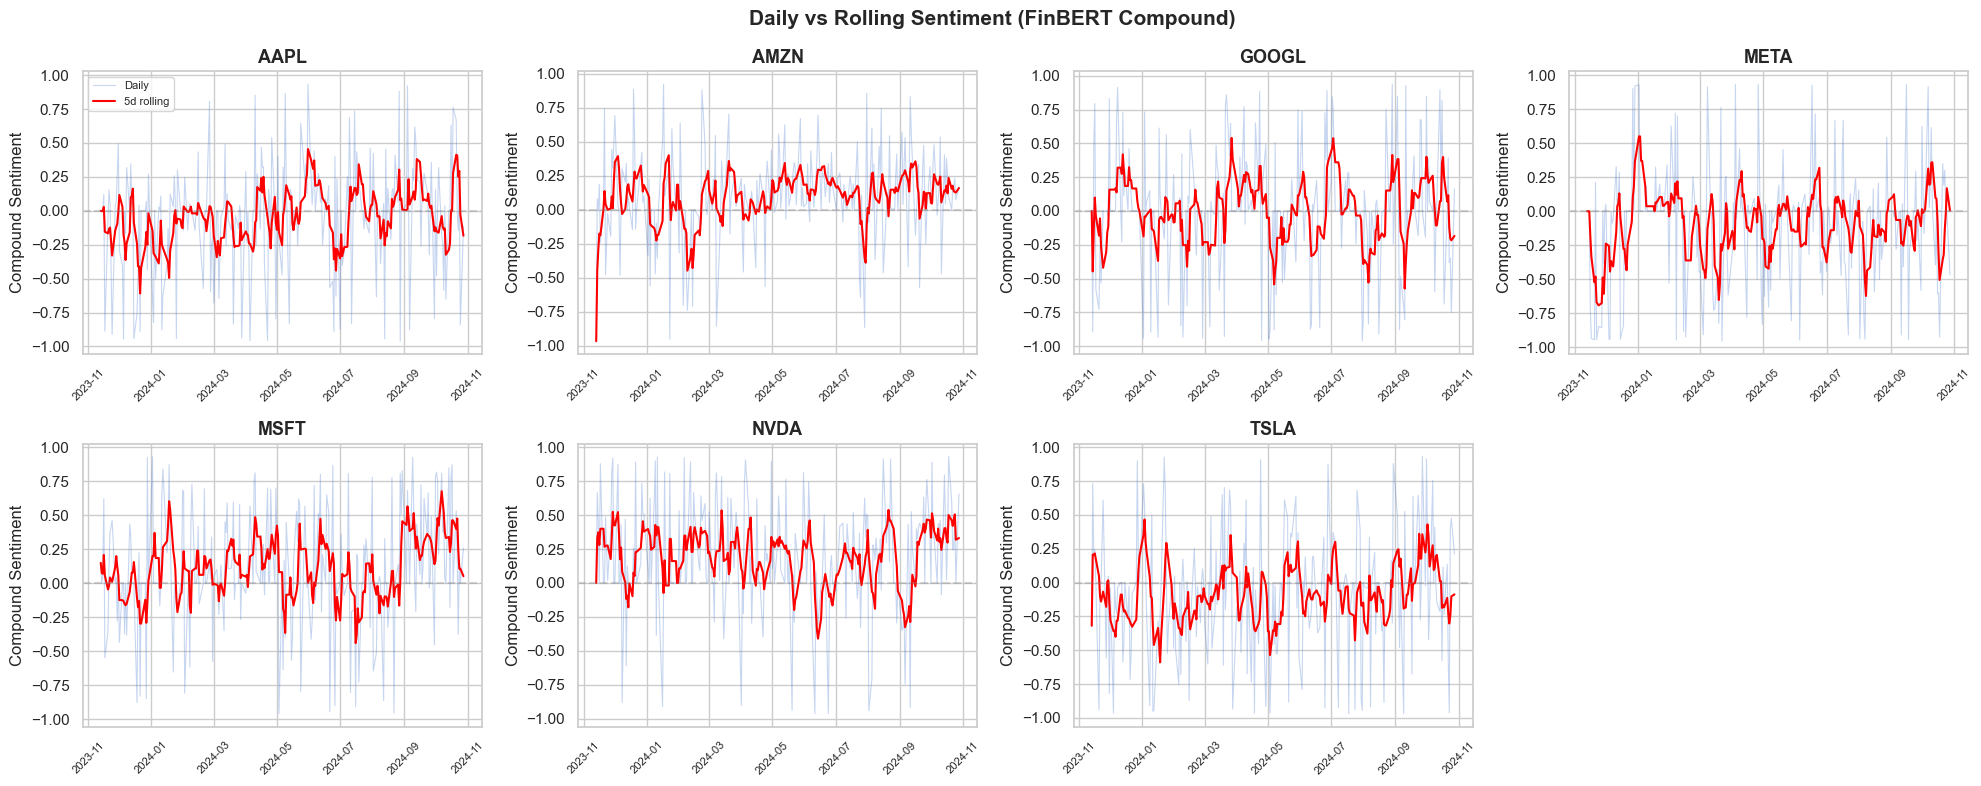

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    sub = full_grid[full_grid['ticker'] == ticker]
    axes[i].plot(sub['date'], sub['sent_compound'], alpha=0.3, linewidth=0.8, label='Daily')
    axes[i].plot(sub['date'], sub['sent_compound_roll5'], linewidth=1.5, color='red', label='5d rolling')
    axes[i].axhline(0, color='gray', linestyle='--', alpha=0.3)
    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_ylabel('Compound Sentiment')
    if i == 0:
        axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Daily vs Rolling Sentiment (FinBERT Compound)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

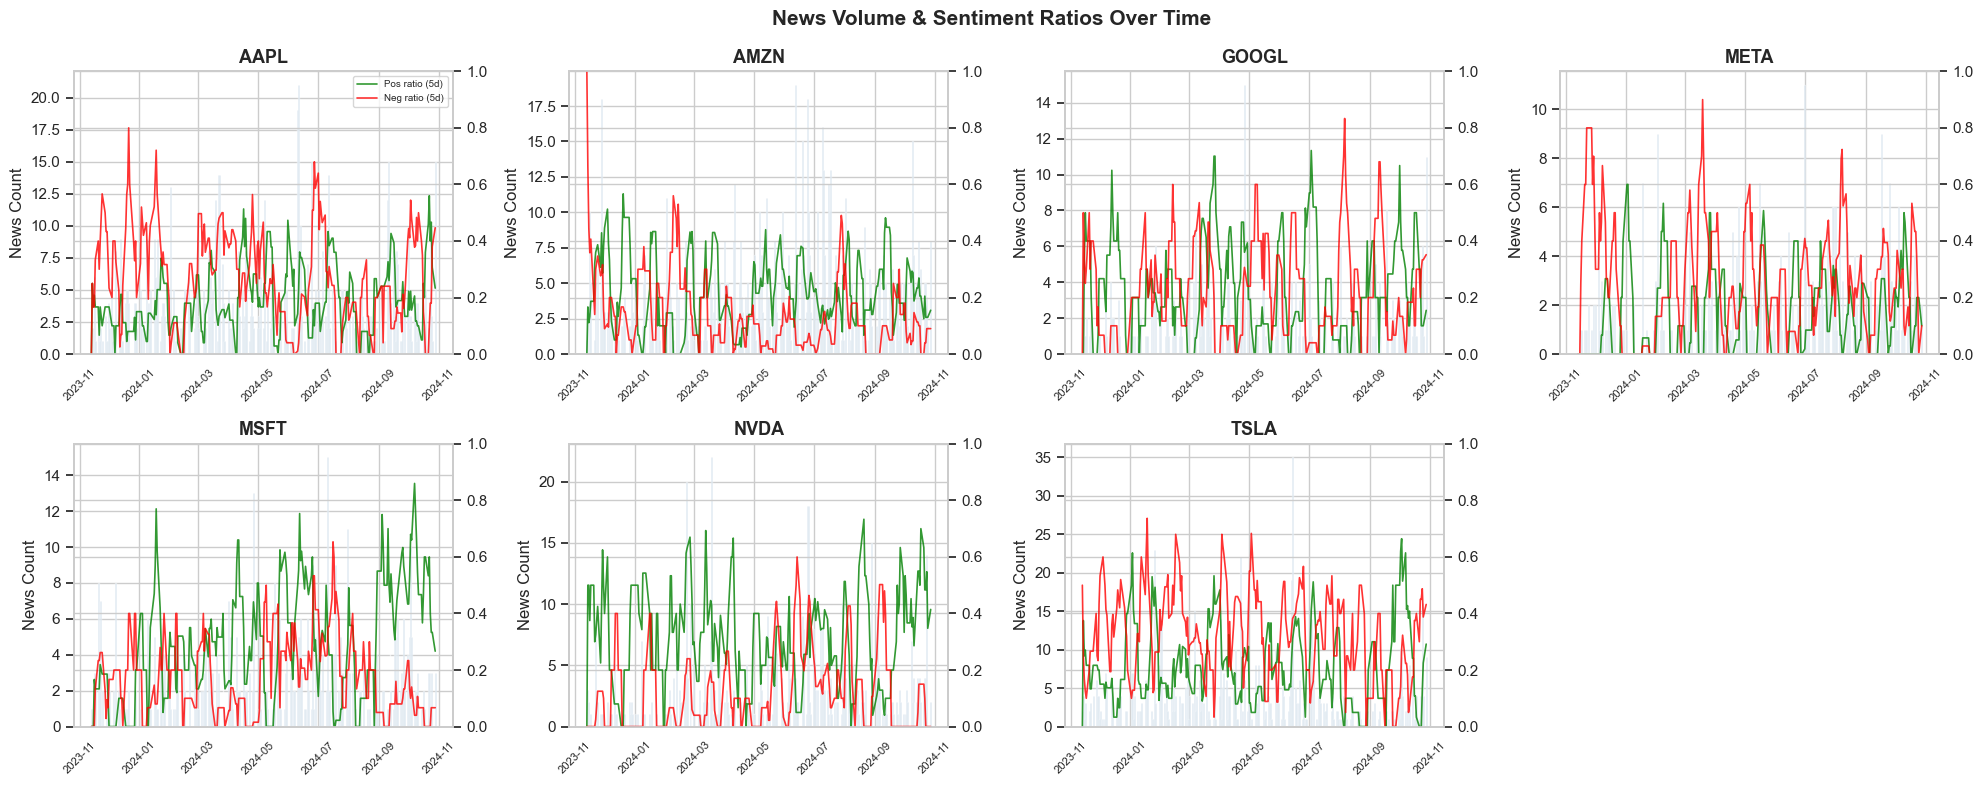

In [13]:
# News volume and sentiment heatmap over time
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    sub = full_grid[full_grid['ticker'] == ticker]
    axes[i].bar(sub['date'], sub['news_count'], width=1, alpha=0.6, color='steelblue')
    ax2 = axes[i].twinx()
    ax2.plot(sub['date'], sub['positive_ratio_roll5'], color='green', linewidth=1.2, alpha=0.8, label='Pos ratio (5d)')
    ax2.plot(sub['date'], sub['negative_ratio_roll5'], color='red', linewidth=1.2, alpha=0.8, label='Neg ratio (5d)')
    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_ylabel('News Count')
    ax2.set_ylim(0, 1)
    if i == 0:
        ax2.legend(fontsize=7, loc='upper right')

axes[-1].set_visible(False)
fig.suptitle('News Volume & Sentiment Ratios Over Time', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Save NLP Features

In [14]:
nlp_feature_cols = (
    ['date', 'ticker', 'has_news', 'news_count']
    + [c for c in full_grid.columns if c.startswith('sent_') or c.startswith('positive') or c.startswith('negative')]
    + emb_pca_cols
)

# Deduplicate column list
nlp_feature_cols = list(dict.fromkeys(nlp_feature_cols))

output_nlp = full_grid[nlp_feature_cols].copy()
output_nlp.to_csv(f'{DATA_DIR}/features_nlp.csv', index=False)

print(f'Saved: features_nlp.csv')
print(f'Shape: {output_nlp.shape}')
print(f'\nColumns ({len(nlp_feature_cols)}):')
for col in nlp_feature_cols:
    print(f'  {col}')

print(f'\nDate range: {output_nlp["date"].min()} to {output_nlp["date"].max()}')
print(f'Rows per ticker:')
display(output_nlp.groupby('ticker').size())

Saved: features_nlp.csv
Shape: (1687, 35)

Columns (35):
  date
  ticker
  has_news
  news_count
  sent_compound
  sent_compound_std
  sent_compound_min
  sent_compound_max
  sent_positive
  sent_negative
  positive_ratio
  negative_ratio
  sent_compound_roll5
  sent_compound_std_roll5
  sent_compound_min_roll5
  sent_compound_max_roll5
  sent_positive_roll5
  sent_negative_roll5
  positive_ratio_roll5
  negative_ratio_roll5
  emb_pca_0
  emb_pca_1
  emb_pca_2
  emb_pca_3
  emb_pca_4
  emb_pca_5
  emb_pca_6
  emb_pca_7
  emb_pca_8
  emb_pca_9
  emb_pca_10
  emb_pca_11
  emb_pca_12
  emb_pca_13
  emb_pca_14

Date range: 2023-11-13 00:00:00 to 2024-10-28 00:00:00
Rows per ticker:


ticker
AAPL     241
AMZN     241
GOOGL    241
META     241
MSFT     241
NVDA     241
TSLA     241
dtype: int64

In [15]:
# Cache raw article-level sentiment for potential reuse
cache_cols = ['datetime', 'ticker', 'headline', 'sent_compound', 'sent_label',
              pos_col, neg_col, 'trading_day']
news_df[cache_cols].to_csv(f'{DATA_DIR}/news_sentiment_cache.csv', index=False)
print(f'Cached article-level sentiment: news_sentiment_cache.csv ({len(news_df)} rows)')

Cached article-level sentiment: news_sentiment_cache.csv (4440 rows)


## Summary

**NLP feature pipeline completed:**

1. **FinBERT sentiment** -- positive / negative / neutral probabilities + compound score per article
2. **Sentence embeddings** -- 384d headline vectors reduced to 15 PCA components
3. **Temporal alignment** -- post-16:00 and weekend news mapped to next trading day
4. **Daily aggregation** -- mean, std, min, max of compound; positive/negative ratios; news count; has_news flag
5. **Rolling smoothing** -- 5-day rolling mean of sentiment features for robustness
6. **Saved outputs** -- `features_nlp.csv` (daily per-ticker) + `news_sentiment_cache.csv` (article-level)

**Next step:** Merge `features_price.csv` + `features_nlp.csv` into the final feature matrix for modeling.